In [8]:
%matplotlib inline

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

from xgboost import XGBClassifier

import shap

In [9]:
df = pd.read_csv("student_dropout_dataset_v3.csv")

df.head()

,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
0,1,22.1,Male,25000.0,Yes,3.36,86.1,2,20.4,Yes,No,5.5,0.96,0.90,0.90,Year 1,Arts,High School,0
1,2,20.7,Male,25000.0,Yes,4.30,68.0,2,44.0,No,No,6.8,1.28,1.20,1.19,Year 3,Engineering,Bachelor,1
2,3,22.4,Male,40183.0,Yes,4.40,70.9,0,48.9,Yes,No,5.5,1.68,1.32,1.32,Year 1,Arts,Master,0
3,4,24.4,Male,NaN,Yes,NaN,82.2,2,38.6,No,No,NaN,1.78,1.77,1.77,Year 1,CS,High School,1
4,5,20.5,Female,25319.0,Yes,4.19,75.7,1,23.0,No,No,7.0,1.48,0.91,0.87,Year 4,Business,Bachelor,0


In [10]:
df = df.drop("Student_ID", axis=1)

categorical = [
    "Gender",
    "Internet_Access",
    "Part_Time_Job",
    "Scholarship",
    "Department",
    "Parental_Education"
]

encoder = LabelEncoder()

for col in categorical:
    df[col] = encoder.fit_transform(df[col])

df.head()

,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
0,22.1,1,25000.0,1,3.36,86.1,2,20.4,1,0,5.5,0.96,0.90,0.90,Year 1,0,1,0
1,20.7,1,25000.0,1,4.30,68.0,2,44.0,0,0,6.8,1.28,1.20,1.19,Year 3,3,0,1
2,22.4,1,40183.0,1,4.40,70.9,0,48.9,1,0,5.5,1.68,1.32,1.32,Year 1,0,2,0
3,24.4,1,NaN,1,NaN,82.2,2,38.6,0,0,NaN,1.78,1.77,1.77,Year 1,2,1,1
4,20.5,0,25319.0,1,4.19,75.7,1,23.0,0,0,7.0,1.48,0.91,0.87,Year 4,1,0,0


# Target Distribution

/tmp/ipykernel_224/2333095436.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


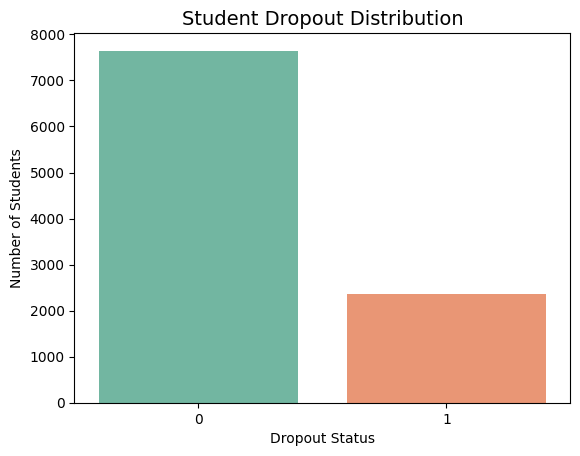

In [12]:
plt.figure()

sns.countplot(
    x="Dropout",
    data=df,
    palette="Set2"
)

plt.title("Student Dropout Distribution", fontsize=14)
plt.xlabel("Dropout Status")
plt.ylabel("Number of Students")

plt.show()

# CGPA vs Dropout

/tmp/ipykernel_224/963159885.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


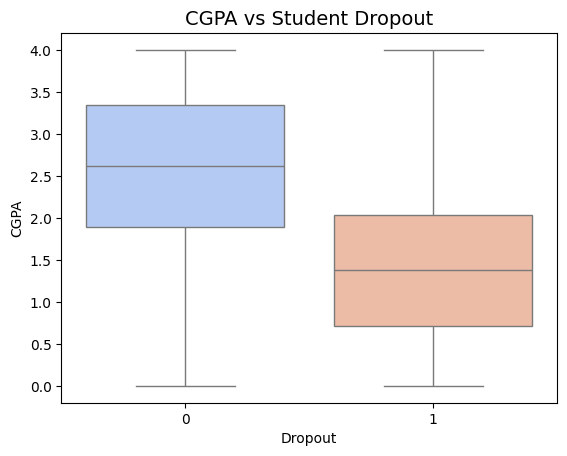

In [13]:
plt.figure()

sns.boxplot(
    x="Dropout",
    y="CGPA",
    data=df,
    palette="coolwarm"
)

plt.title("CGPA vs Student Dropout", fontsize=14)

plt.show()

# Attendance vs Dropout

/tmp/ipykernel_224/1362856754.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


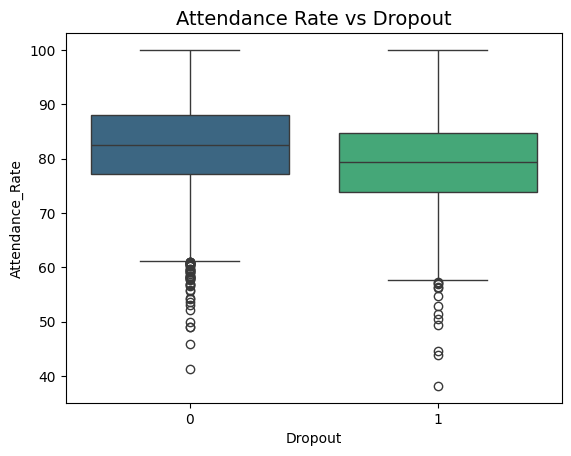

In [14]:
plt.figure()

sns.boxplot(
    x="Dropout",
    y="Attendance_Rate",
    data=df,
    palette="viridis"
)

plt.title("Attendance Rate vs Dropout", fontsize=14)

plt.show()

# Study Hours vs Dropout

/tmp/ipykernel_224/2076161253.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


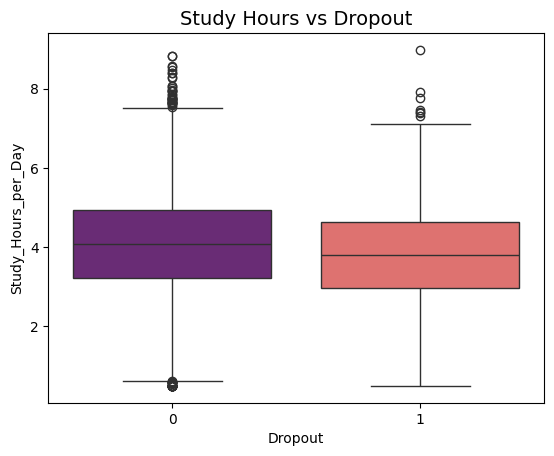

In [15]:
plt.figure()

sns.boxplot(
    x="Dropout",
    y="Study_Hours_per_Day",
    data=df,
    palette="magma"
)

plt.title("Study Hours vs Dropout", fontsize=14)

plt.show()

# Correlation Heatmap

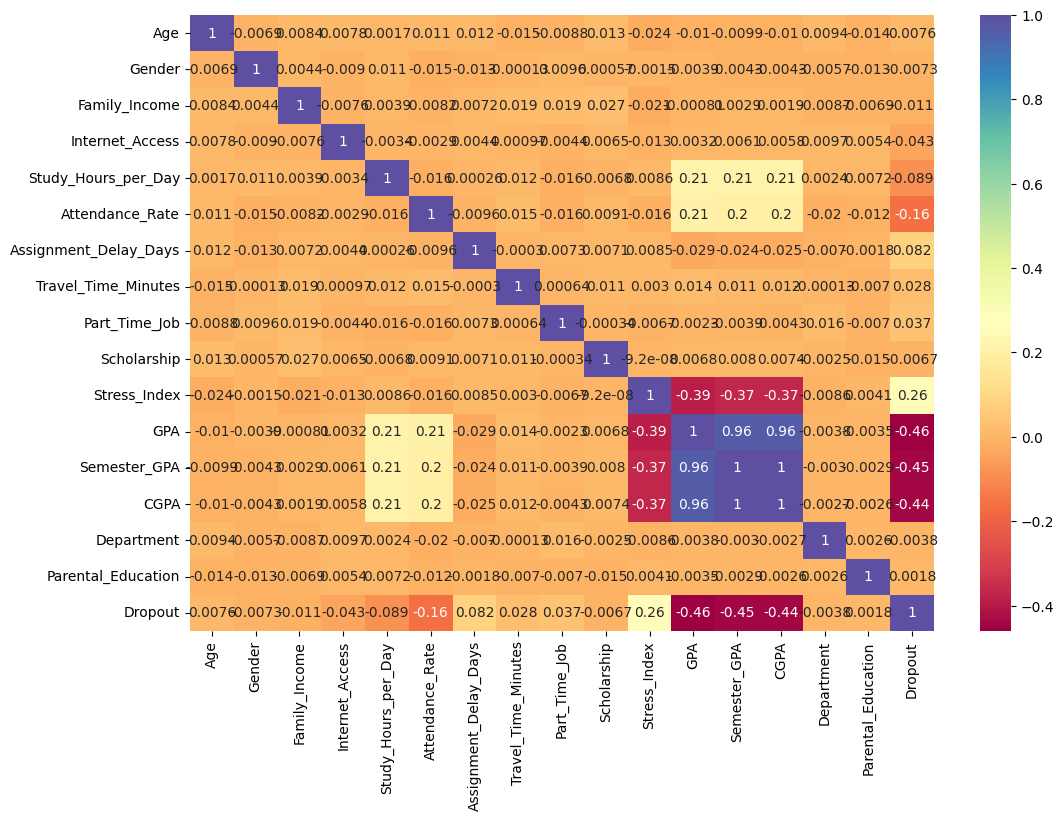

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns
numeric_df = df.select_dtypes(include='number')

plt.figure(figsize=(12,8))
sns.heatmap(
    numeric_df.corr(),
    cmap="Spectral",
    annot=True,   # can also keep False
)
plt.show()

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

# -----------------------------
# SPLIT FEATURES AND TARGET
# -----------------------------
X = df.drop("Dropout", axis=1)
y = df["Dropout"]

# -----------------------------
# TRAIN-TEST SPLIT
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# HANDLE MISSING VALUES
# -----------------------------
# Numeric columns
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
num_imputer = SimpleImputer(strategy='mean')
X_train[num_cols] = num_imputer.fit_transform(X_train[num_cols])
X_test[num_cols] = num_imputer.transform(X_test[num_cols])

# Categorical columns
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns
cat_imputer = SimpleImputer(strategy='most_frequent')  # or fill_value='missing'
X_train[cat_cols] = cat_imputer.fit_transform(X_train[cat_cols])
X_test[cat_cols] = cat_imputer.transform(X_test[cat_cols])

# -----------------------------
# ENCODE CATEGORICAL FEATURES
# -----------------------------
for col in cat_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])

# -----------------------------
# SCALE NUMERIC FEATURES
# -----------------------------
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

# -----------------------------
# DEFINE MODELS
# -----------------------------
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(eval_metric="logloss"),
    "Neural Network": MLPClassifier(max_iter=500)
}

scores = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    scores[name] = accuracy_score(y_test, predictions)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


In [29]:
#MODEL PERFORMANCE
results = pd.DataFrame(
    scores.items(),
    columns=["Model","Accuracy"]
)

# Show sorted results
print(results.sort_values(by="Accuracy", ascending=False))

                 Model  Accuracy
0  Logistic Regression    0.8105
2        Random Forest    0.8075
3              XGBoost    0.7965
4       Neural Network    0.7855
1        Decision Tree    0.7310


In [31]:
# TRAIN BEST MODEL (Logistic Regression)

# Initialize the model
best_model = LogisticRegression(max_iter=1000, random_state=42)

# Train the model
best_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [54]:
!pip install shap

In [55]:
import shap
import matplotlib.pyplot as plt

shap.initjs()

In [63]:
X_train = X_train.astype(float)
X_test = X_test.astype(float)

In [64]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000, random_state=42)

In [65]:
explainer = shap.LinearExplainer(log_model, X_train)

shap_values = explainer(X_test)

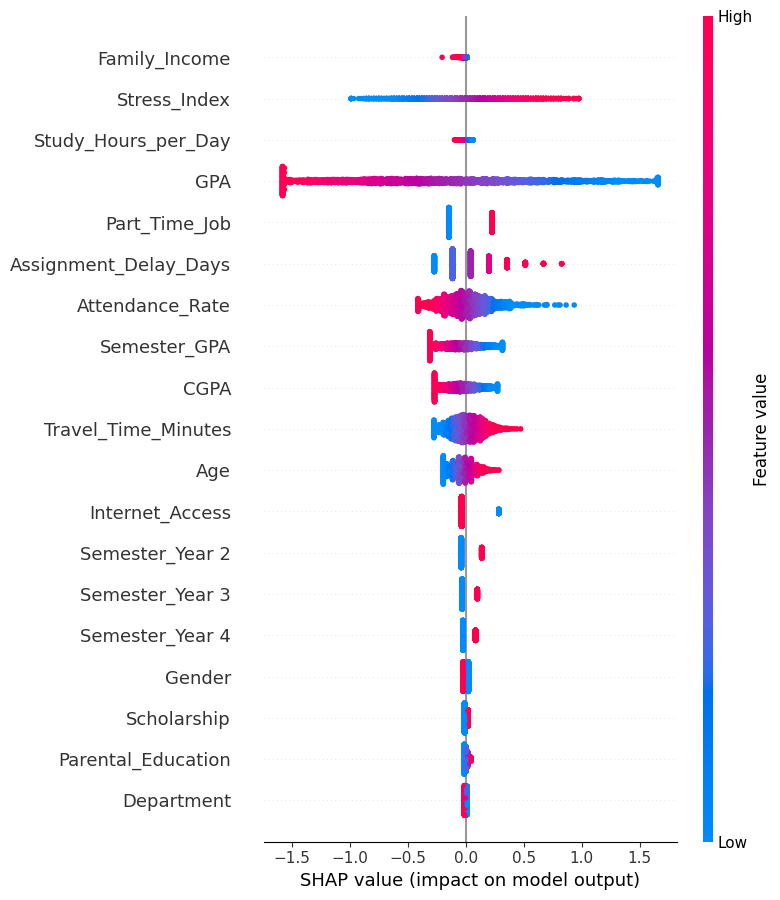

In [66]:
#SHAP Summary Plot (Beeswarm)

shap.summary_plot(
    shap_values.values,
    X_test,
    feature_names=X_test.columns
)

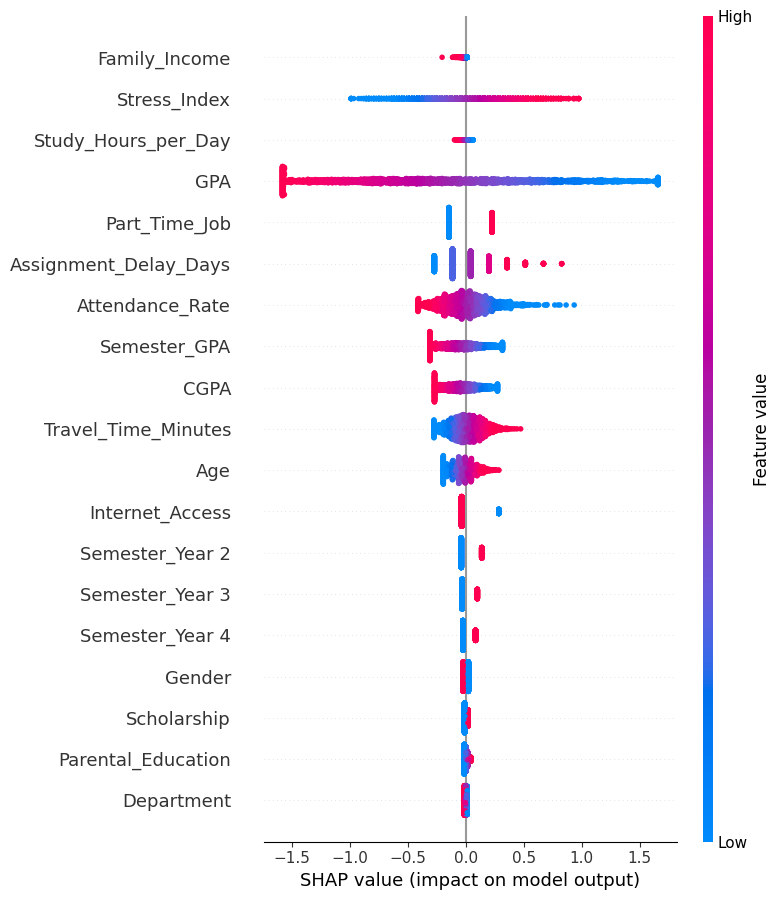

In [67]:
#SUMMARY PLOT

shap.summary_plot(
    shap_values.values,
    X_test,
    feature_names=X_test.columns
)

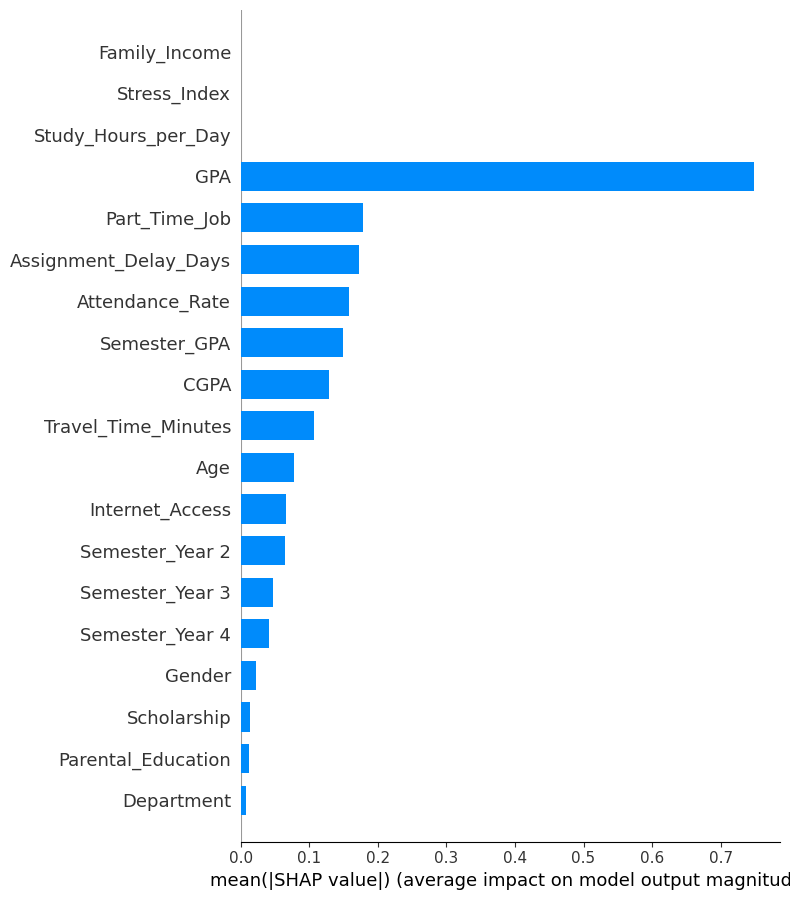

In [68]:
#BAR PLOT

shap.summary_plot(
    shap_values.values,
    X_test,
    plot_type="bar",
    feature_names=X_test.columns
)

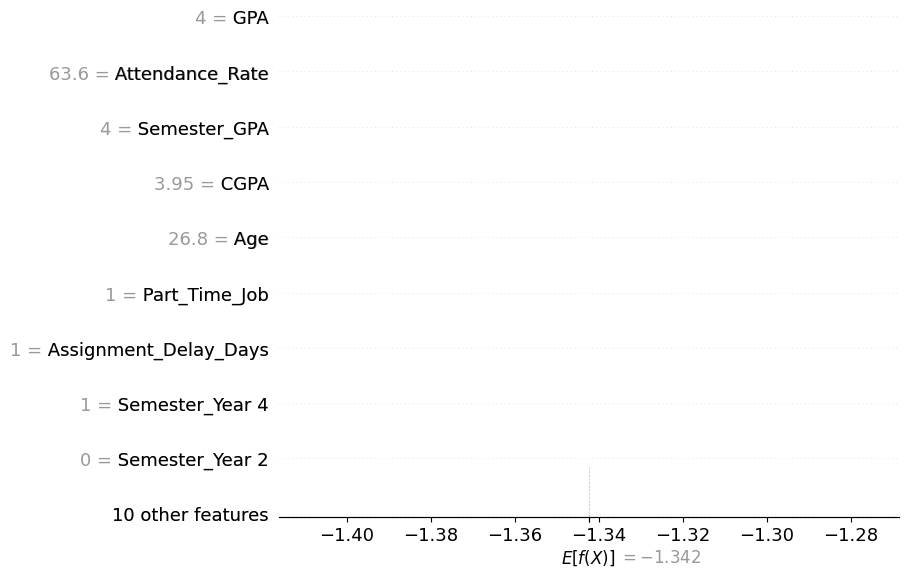

In [69]:
#WATERFALL PLOT

shap.plots.waterfall(shap_values[0])

In [70]:
import joblib

joblib.dump(log_model, "logistic_model.pkl")

['logistic_model.pkl']